In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

In [2]:
df = pd.read_csv("/content/Students suspicious behaviors detection dataset_V1.csv")
print("Shape:", df.shape)
print(df.head())

Shape: (5500, 38)
   face_present  no_of_face      face_x      face_y      face_w      face_h  \
0             1           1  262.579536  312.062903  151.787758  151.787567   
1             1           1  260.704193  312.342424  154.607773  154.607735   
2             1           1  264.240570  311.801834  148.079300  148.079195   
3             1           1  262.811012  314.088278  151.014061  151.014175   
4             1           1  269.176426  312.678709  148.739681  148.739605   

   left_eye_x  left_eye_y  right_eye_x  right_eye_y  ...  phone_conf  \
0  307.918568  354.478884   373.059845   353.494949  ...         0.0   
1  305.797863  354.197273   372.084160   357.747831  ...         0.0   
2  304.438133  351.268072   368.618050   353.264036  ...         0.0   
3  304.091930  355.737219   369.532318   355.841103  ...         0.0   
4  310.720120  354.326448   374.389267   350.510445  ...         0.0   

   gaze_on_script  gaze_direction  gazePoint_x  gazePoint_y  pupil_left_x 

In [3]:
print("\nNull values:")
print(df.isnull().sum()[df.isnull().sum() > 0])


Null values:
head_pose          569
gaze_direction    1051
dtype: int64


In [4]:
df['head_pose']      = df['head_pose'].fillna('unknown')
df['gaze_direction'] = df['gaze_direction'].fillna('unknown')

In [5]:
le = LabelEncoder()
df['head_pose']      = le.fit_transform(df['head_pose'])
df['gaze_direction'] = le.fit_transform(df['gaze_direction'])


Label Distribution:
label
0    2881
1    2619
Name: count, dtype: int64


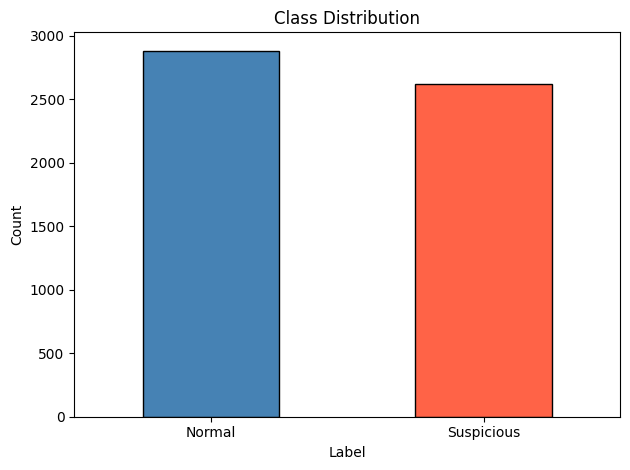

In [6]:
print("\nLabel Distribution:")
print(df['label'].value_counts())

df['label'].value_counts().rename({0: 'Normal', 1: 'Suspicious'}).plot(
    kind='bar', color=['steelblue', 'tomato'], edgecolor='black'
)
plt.title("Class Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [7]:
X = df.drop(columns=['label'])
y = df['label']

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nTraining samples : {len(X_train)}")
print(f"Testing  samples : {len(X_test)}")


Training samples : 4400
Testing  samples : 1100


In [9]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [10]:
y_pred = model.predict(X_test)

In [11]:
accuracy = accuracy_score(y_test, y_pred)
print(f"\nModel Accuracy: {accuracy * 100:.2f}%")


Model Accuracy: 99.64%


In [12]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Normal (0)', 'Suspicious (1)']))


Classification Report:
                precision    recall  f1-score   support

    Normal (0)       0.99      1.00      1.00       569
Suspicious (1)       1.00      0.99      1.00       531

      accuracy                           1.00      1100
     macro avg       1.00      1.00      1.00      1100
  weighted avg       1.00      1.00      1.00      1100



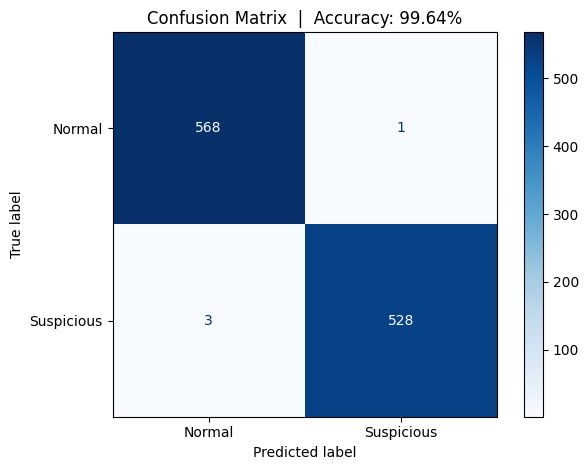

In [13]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Normal', 'Suspicious'])
disp.plot(cmap='Blues')
plt.title(f"Confusion Matrix  |  Accuracy: {accuracy*100:.2f}%")
plt.tight_layout()
plt.show()

/tmp/ipykernel_954/4189003597.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_scores, y=top_features, palette='viridis')


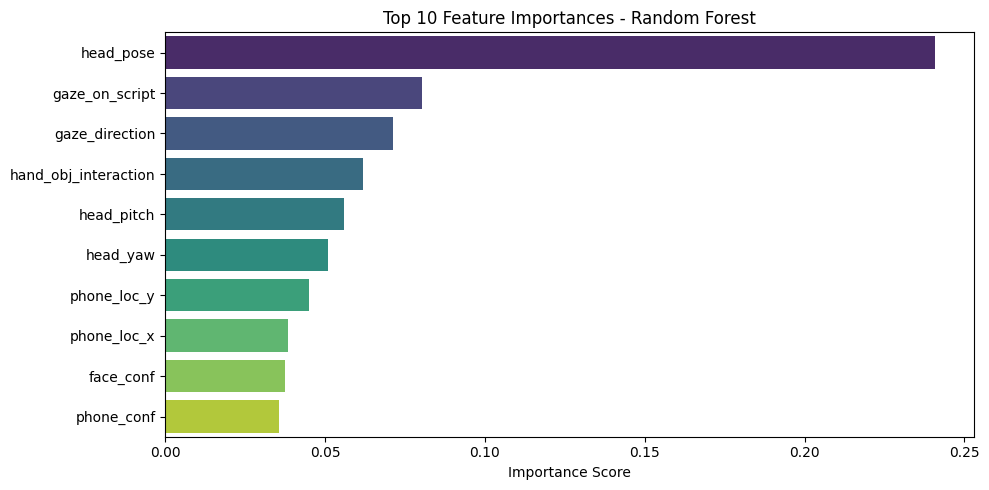

In [14]:
importances = model.feature_importances_
indices = np.argsort(importances)[::-1][:10]
top_features = [X.columns[i] for i in indices]
top_scores   = [importances[i] for i in indices]

plt.figure(figsize=(10, 5))
sns.barplot(x=top_scores, y=top_features, palette='viridis')
plt.title("Top 10 Feature Importances - Random Forest")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

In [15]:
new_sample = X_test.iloc[[0]]
prediction    = model.predict(new_sample)
probabilities = model.predict_proba(new_sample)[0]
label = "Suspicious 🔴" if prediction[0] == 1 else "Normal 🟢"

print(f"\nPredicted Behaviour   : {label}")
print(f"Normal Probability    : {probabilities[0]*100:.2f}%")
print(f"Suspicious Probability: {probabilities[1]*100:.2f}%")


Predicted Behaviour   : Normal 🟢
Normal Probability    : 84.00%
Suspicious Probability: 16.00%
